<h1>Time Series Visualizer Data Analysis Project<h1>

<dl>
<dt> <b>Context</b></dt>
<dd>
For this project you will visualize time series data using a line chart, bar chart, and box plots. You will use Pandas, Matplotlib, and Seaborn to visualize a dataset containing the number of page views each day on the freeCodeCamp.org forum from 2016-05-09 to 2019-12-03. The data visualizations will help you understand the patterns in visits and identify yearly and monthly growth.
</dd><br>

<dt><b>Instruction</b></dt><br>
<p style="margin-left: 20px;">Use the data to complete the following tasks:</p>
<ol><dd>
<li>Clean the data by filtering out days when the page views were in the top 2.5% of the dataset or bottom 2.5% of the dataset.</li><br>

<li>Create a draw_line_plot function that uses Matplotlib to draw a line chart similar to the image below. The title should be Daily freeCodeCamp Forum Page Views 5/2016-12/2019. The label on the x axis should be Date and the label on the y-axis should be Page Views.</li><br>
 

<img src="Picture1.png" alt="Image description">


<li>Create a draw_bar_plot function that draws a bar chart similar to the one below

<img src="Picture2.png">.

It should show average daily page views for each month grouped by year. The legend should show month labels and have a title of Months. On the chart, the label on the x-axis should be Years and the label on the y-axis should be Average Page Views.</li><br>

<li>Create a draw_box_plot function that uses Seaborn to draw two adjacent box plots similar to the one below

<img src="Picture3.png">.</li><br> 

<li>These box plots should show how the values are distributed within a given year or month and how it compares over time.</li><br>

<li>The title of the first chart should be Year-wise Box Plot (Trend) and the title of the second chart should be Month-wise Box Plot (Seasonality).</li><br>

<li>Make sure the month labels on bottom start at Jan and the x and y axis are labeled correctly. The boilerplate includes commands to prepare the data.</li><br>

<li>For each chart, make sure to use a copy of the data frame.</li><br>

<b>NOTE:</b>The boilerplate also includes commands to save and return the image.
</dd></ol><br>

<dt><b>Development</b></dt>
<p style="margin-left: 30px;">Write your code in time_series_visualizer.py. For development, you can use main.py to test your code.</p><br>

<dt><b>Testing</b></dt>
<p style="margin-left: 30px;">The unit tests for this project are in test_module.py. We imported the tests from test_module.py to main.py for your convenience.</p><br>

<dt><b>Submitting</b></dt>
<p style="margin-left: 30px;">Copy your project's URL and submit it to freeCodeCamp.</p>
</dl>

<h4>Import the necessary Libraries and Functions: Load the Data</h4>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('fcc-forum-pageviews.csv')
print(df.head())

         date  value
0  2016-05-09   1201
1  2016-05-10   2329
2  2016-05-11   1716
3  2016-05-12  10539
4  2016-05-13   6933


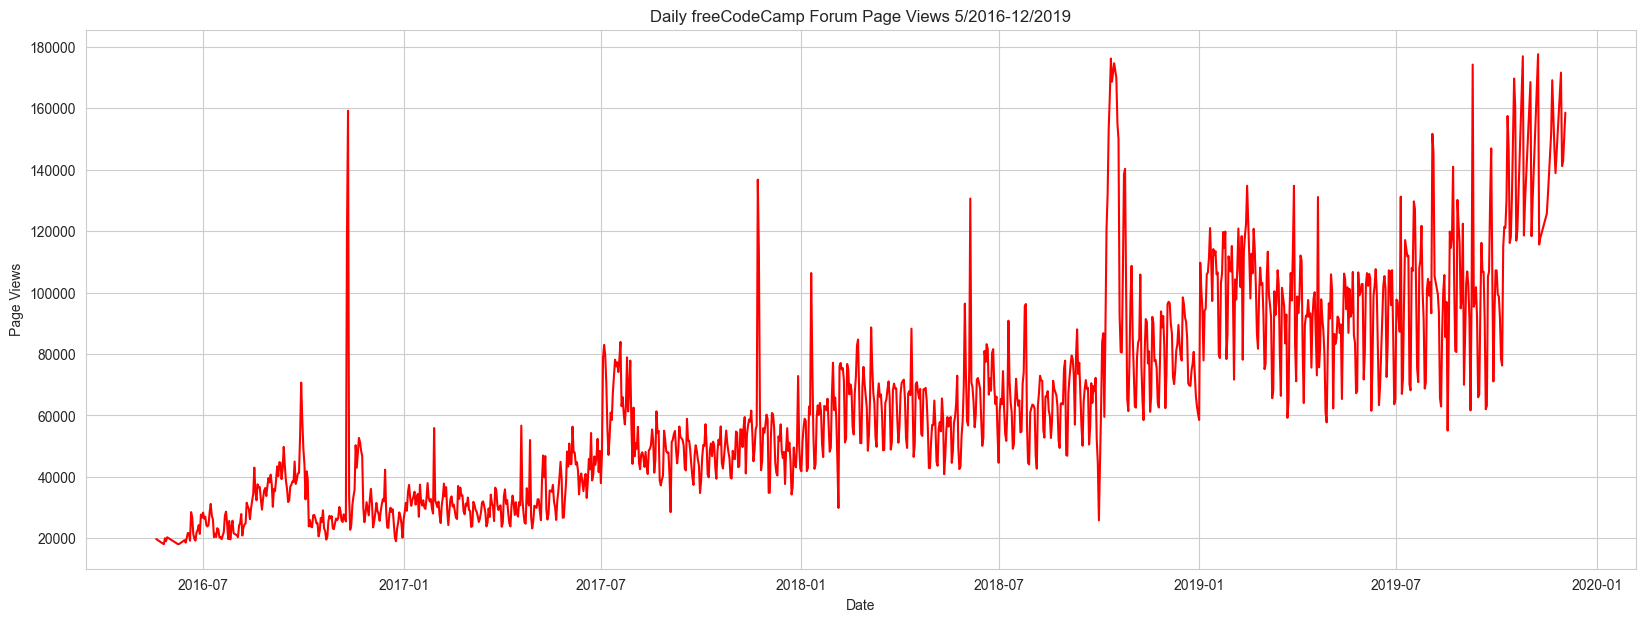

In [8]:
# Clean the Date Column by filtering possible outliers
df = df.loc[(df['value'] >= df['value'].quantile(0.025)) & (df['value'] <= df['value'].quantile(0.975))]

# Convert 'date' column to datetime if it isn't already
df['date'] = pd.to_datetime(df['date'])

# Set figure size to match the wide aspect ratio of the image
plt.figure(figsize=(20, 7))

# Plot the data
plt.plot(df['date'], df['value'], color='red')

# Add title and labels
plt.title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
plt.xlabel('Date')
plt.ylabel('Page Views')
# Show the plot
plt.show()


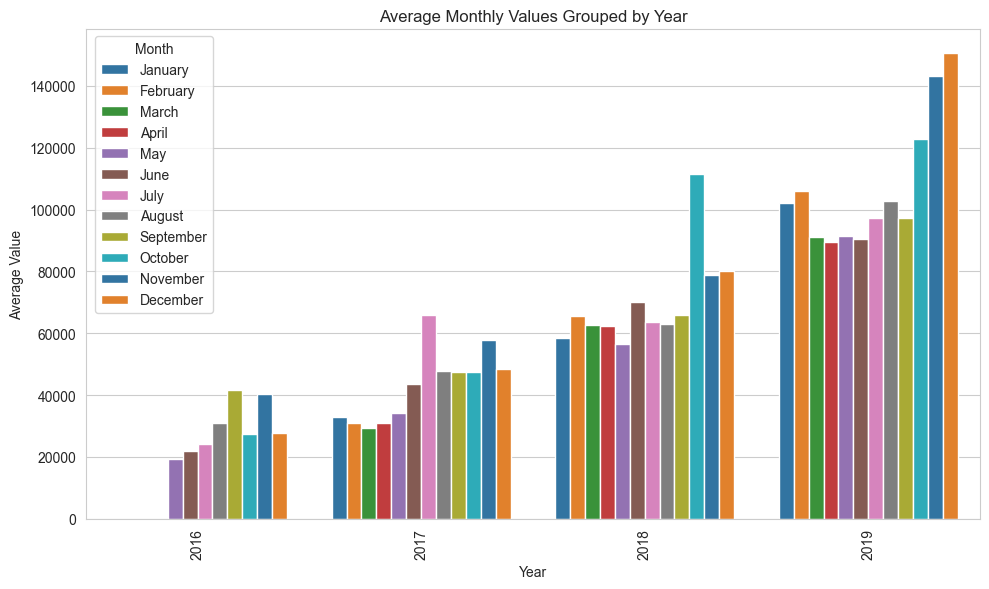

In [30]:
# Create The Date Columns
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['year'] = df['date'].dt.year

# Create a month order list
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Group by year and month, calculate mean
grouped = df.groupby(['year', 'month_name']).agg({'value': 'mean'}).reset_index()

# Convert 'month_name' to a categorical type to preserve order
grouped['month_name'] = pd.Categorical(grouped['month_name'], categories=month_order, ordered=True)

# Sort by year and month
grouped = grouped.sort_values(['year', 'month_name'])

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='year', y='value', hue='month_name', palette='tab10')

plt.title('Average Monthly Values Grouped by Year')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.xticks(rotation=90)
plt.legend(title='Month', bbox_to_anchor=(0.15, 1))
plt.tight_layout()
plt.show()


